**Notes**
- Before proceeding to this step, make sure to remove invalid images (i.e., GSV image that has error message in the image, easily identifiable since all comes with ~9 KB size) and store cleaned GSV images under this path: "./output/1/error_free".
- Install Ollama (both the app and the python package) and the corresponding Llava model (llava:7b-v1.6-mistral-q4_0). More details: https://docs.ollama.com/

In [1]:
import base64
import json
import logging
import math
import shutil
from datetime import datetime as dt
from io import BytesIO
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import ollama
import pandas as pd
import shapely
from PIL import Image
from tqdm import tqdm

# Filter out buildings that does not intersect the road

In [2]:
def setup_logging(log_dir):
    """
    Set up logging configuration.
    
    Args:
        log_dir (str): Directory to store log files.
        
    Returns:
        Configured logger instance.
    """
    log_dir.mkdir(parents=True, exist_ok=True)
    log_file = log_dir / "2.log"
    
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)

def get_road_intersected_penjaringan_buildings(ADM_PATH, BUILDINGS_PATH, ROAD_PATH):
    """
    Get road-intersected buildings in Penjaringan.

    Args:
        ADM_PATH (str): Path to the administrative area data file.
        BUILDINGS_PATH (str): Path to the buildings data file.
        ROAD_PATH (str): Path to the road network data file.

    Returns:
        A tuple of Penjaringan buildings and road-intersected Penjaringan buildings.
    """
    logger.info(f"Reading administrative area data, building data, and roads data....")
    penjaringan_gdf = gpd.read_parquet(ADM_PATH)[["geometry"]].to_crs("EPSG:32748")
    buildings_gdf = gpd.read_parquet(BUILDINGS_PATH).to_crs("EPSG:32748")
    roads_gdf = gpd.read_parquet(ROAD_PATH).to_crs("EPSG:32748")

    # Get road-intersected buildings
    logger.info(f"Clipping building and roads data to Penjaringan....")
    penjaringan_buildings = buildings_gdf.clip(penjaringan_gdf.dissolve())
    penjaringan_roads = roads_gdf.clip(penjaringan_gdf.dissolve())
    
    logger.info(f"Showing Penjaringan roads....")
    fig, ax = plt.subplots()
    penjaringan_roads.plot(ax=ax)
    plt.show()

    buffer_size = float(roads_gdf[["LBRJLN"]].quantile(.95).iloc[0])  # Get a road buffer that represent 95th percentile of Jakarta’s road width
    road_buff = gpd.GeoDataFrame(roads_gdf.buffer(buffer_size)).set_geometry(0)
    road_intersected_penjaringan_buildings = gpd.sjoin(penjaringan_buildings, road_buff, how="inner", predicate="intersects").drop_duplicates("id")
    
    logger.info(f"Showing Penjaringan buildings (white) and road-intersected buildings (red)....")
    fig, ax = plt.subplots()
    penjaringan_buildings.plot(ax=ax, color='white', edgecolor='black', linewidth=0.1)
    road_intersected_penjaringan_buildings.plot(ax=ax, color='red', edgecolor='black', linewidth=0.1)
    plt.show()

    return penjaringan_buildings, road_intersected_penjaringan_buildings

def plot_intersected_buildings_by_rw(RW_PATH, kelurahan, rw, penjaringan_buildings, road_intersected_penjaringan_buildings):
    """
    Plot intersected buildings in specified RW.

    Args:
        RW_PATH (str): Path to the RW data file.
        kelurahan (str): Name of the specified kelurahan where the RW is located.
        rw (str): The specified RW in the kelurahan.
        penjaringan_buildings (GeoDataFrame): Buildings in Penjaringan.
        road_intersected_penjaringan_buildings (GeoDataFrame): Road-intersected buildings in Penjaringan
    Return:
        A plot that highlights intersected buildings in the specified RW.
    """
    rw_gdf = gpd.read_parquet(RW_PATH).to_crs("EPSG:32748")
    rw_filter = rw_gdf[(rw_gdf.WADMKD == kelurahan) & (rw_gdf.WADMRW == rw)].buffer(5)

    penjaringan_buildings_rw = penjaringan_buildings.clip(rw_filter)
    road_intersected_penjaringan_buildings_rw = road_intersected_penjaringan_buildings.clip(rw_filter)

    logger.info(f"Showing Penjaringan buildings (white) and road-intersected buildings (red) in RW {rw}, Kelurahan {kelurahan.capitalize()}....")
    fig, ax = plt.subplots()
    penjaringan_buildings_rw.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
    road_intersected_penjaringan_buildings_rw.plot(ax=ax, color='red', edgecolor='black', linewidth=0.5)

    return plt.show()

In [3]:
# Configuration
INTERMEDIATE_DIR = Path("./temp/2")
OUTPUT_DIR = Path("./output/2")

# Create directories if they don't exist
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ADM_PATH = "./input/adm_penjaringan.gzip"
BUILDINGS_PATH = "./output/0/buildings.gzip"
ROAD_PATH = "./input/road_jkt_line.gzip"
RW_PATH = "./input/rw_jakarta.gzip"

PARTITION_HELPER_PATH = "./helper/filtering_partitions.json"
ERROR_FREE_GSV_DIR = Path("./output/1/error_free")

MODEL_NAME = "llava:7b-v1.6-mistral-q4_0"
PROMPT = """
Your task is to predict if the image provided contains building(s), based on the image provided by users.

You will be presented with <building>, an image containing a main building located roughly at the center of the image.

Your goal is to infer if buildings are present or not <building> in the image.
If the image does not contain a building located roughly at the center of the image, then the image does not contain a building.
It is not your goal to infer if an object other than building in the image is inside or near a building.
Only select <building> from this list: ["Yes", "No"].

Organize your answer in the JSON format containing two keys: 
{
    "answer": <building>,
    "reason": ""
}

The meaning of two keys:
- "answer": the most likely <building> chosen from the provided list.
- "reason": a concise explanation supporting your prediction, considering the availability of building features information in the image specific to buildings located in DKI Jakarta Province, Indonesia. Please do not use line breaks in the reason.
"""

logger = setup_logging(INTERMEDIATE_DIR)

2025-10-27 15:17:13,249 - INFO - Reading administrative area data, building data, and roads data....
2025-10-27 15:17:14,682 - INFO - Clipping building and roads data to Penjaringan....
2025-10-27 15:17:28,422 - INFO - Showing Penjaringan roads....


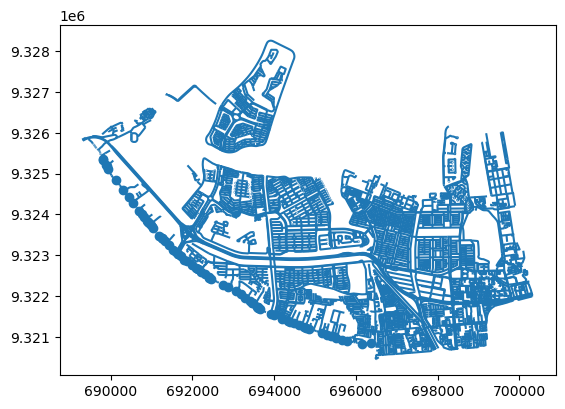

2025-10-27 15:17:31,630 - INFO - Showing Penjaringan buildings (white) and road-intersected buildings (red)....


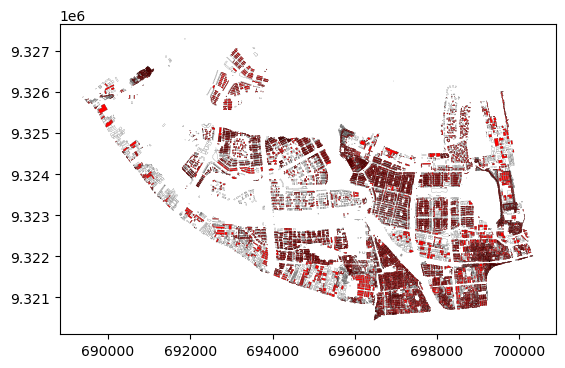

2025-10-27 15:17:37,433 - INFO - Showing Penjaringan buildings (white) and road-intersected buildings (red) in RW 022, Kelurahan Pluit....


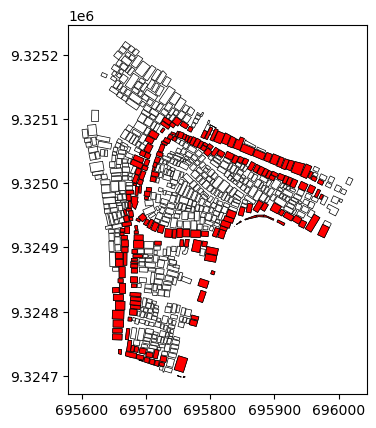

2025-10-27 15:17:37,687 - INFO - Showing Penjaringan buildings (white) and road-intersected buildings (red) in RW 004, Kelurahan Kamal muara....


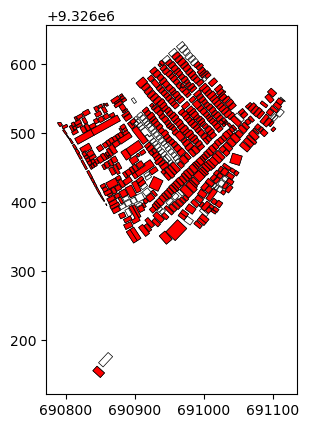

In [4]:
# Get road-intersected buildings in Penjaringan
penjaringan_buildings, road_intersected_penjaringan_buildings = get_road_intersected_penjaringan_buildings(ADM_PATH, BUILDINGS_PATH, ROAD_PATH)

# Plot intersected buildings in specified RW
kelurahan_list = ["PLUIT", "KAMAL MUARA"]
rw_list = ["022", "004"]

for kelurahan_rw in zip(kelurahan_list, rw_list):
    plot_intersected_buildings_by_rw(RW_PATH, kelurahan_rw[0], kelurahan_rw[1], penjaringan_buildings, road_intersected_penjaringan_buildings)

# Filter out obstructed building images using LLaVA

In [5]:
def create_filtering_partitions_helper(road_intersected_penjaringan_buildings, filter_img_time=8, save=False, output_path=None):
    """
    Create filtering partitions to help LLaVA filtering process.

    Args:
        road_intersected_penjaringan_buildings (GeoDataFrame): Road-intersected buildings in Penjaringan.
        filter_img_time (int, optional): Time (s) for the VLM to process an image (Default: 8).
        save (bool, optional): Whether to save the helper locally (Default: False).
        output_path (str, optional): Path to the output helper file (Default: None).

    Returns:
        Filtering partitions helper dictionary.
    """
    logger.info(f"Creating partitions for filtering....")
    ids_to_filter = road_intersected_penjaringan_buildings.id.sort_values()
    filter_img_time = filter_img_time  # Time to filter one image in seconds

    # Set target partition size: ~1 hour/partition
    rows_per_partition = math.ceil((60 * 60) / filter_img_time)
    partitions = math.ceil(len(ids_to_filter) / rows_per_partition)

    partition_dict = {}
    for i in range(partitions):
        start_idx = rows_per_partition * i
        end_idx = min(start_idx + rows_per_partition, len(ids_to_filter))
        partition_dict[f"partition_{i}"] = ids_to_filter.iloc[start_idx:end_idx].tolist()

    if save:
        with open(output_path, 'w') as outfile:
            json.dump(partition_dict, outfile)

    logger.info(f"{len(list(partition_dict.keys()))} partitions created (starting from Partition 0).")
    return partition_dict

def filter_img(img_path, MODEL_NAME, PROMPT, img_size=512, seed=123, temperature=0.5):
    """
    Filter an image using LLaVA.

    Args:
        img_path (str): Path of the image to be filtered.
        MODEL_NAME (str): VLM model name that will filter the image.
        PROMPT (str): Prompt input for the VLM to do image filtering.
        img_size (int, optional): Specified image size (height×length) as input to the model (Default: 512).
        seed (int, optional): Seed for the VLM for reproducibility (Default: 123).
        temperature (float, optional): Controls the randomness and creativity of the model's output (0-1) (Default: 0.5).

    Returns:
        A tuple of filtered answer and reason.
    """
    with Image.open(img_path) as im:
        resized_im = im.resize((img_size, img_size))
        byte_arr = BytesIO()
        resized_im.save(byte_arr, format='PNG')
        image_base64 = base64.b64encode(byte_arr.getvalue()).decode('utf-8')

    predict = ollama.chat(
        model=MODEL_NAME,
        messages=[
            {
                'role': 'user',
                'content': PROMPT,
                'images': [image_base64]
            }
        ],
        format="json",
        options={
            "seed": seed,
            "temperature": temperature
        }
    )

    prediction = predict['message']['content']
    prediction_json = json.loads(prediction)
    img_id = img_path.stem.split("_")[0]
    
    return prediction_json["answer"], prediction_json["reason"]

def filter_partitions(ERROR_FREE_GSV_DIR, MODEL_NAME, PROMPT, INTERMEDIATE_PATH, start_partition, end_partition, partition_dict):
    """
    Filter partitions containing images using LLaVA.

    Args:
        ERROR_FREE_GSV_DIR (str): Path to the directory containing error-free GSV images.
        MODEL_NAME (str): VLM model name that will filter the image.
        PROMPT (str): Prompt input for the VLM to do image filtering.
        INTERMEDIATE_PATH (str): Path to save the partition of filtering results.
        start_partition (int): Start partition number.
        end_partition (int): End partition number.
        partition_dict (dict): Dictionary containing partitions and their IDs.
    """
    for partition_num in range(start_partition, end_partition + 1):
        start_time = dt.now()
        logger.info(f"Filtering partition {partition_num}....")
        
        ids_to_filter = partition_dict[f"partition_{partition_num}"]
        
        jpeg_images = [img for img in Path(ERROR_FREE_GSV_DIR).iterdir() if img.suffix == ".jpeg"]
        
        results = []
        for image in tqdm(jpeg_images, desc=f"Partition {partition_num}", unit="image", leave=True):
            img_id = int(image.stem.split("_")[0])
            if img_id in ids_to_filter:
                answer, reason = filter_img(
                    img_path=image,
                    MODEL_NAME=MODEL_NAME,
                    PROMPT=PROMPT
                )
                results.append((img_id, answer, reason))
        
        elapsed = dt.now() - start_time
        minutes, seconds = divmod(elapsed.total_seconds(), 60)
        tqdm.write(f"\nPartition {partition_num} finished in {minutes:.1f}m {seconds:.1f}s")
        tqdm.write("Saving the result....")
        
        parquet_path = INTERMEDIATE_PATH / Path(f"partition_{partition_num}.gzip")
        
        df = pd.DataFrame(results, columns=["id", "qualified", "reason"]).astype({
            "id": "int32",
            "qualified": str,
            "reason": str
        })
        
        df.to_parquet(parquet_path, compression="gzip", index=False)
        tqdm.write(f"Result saved at: {parquet_path}\n")

def save_filtered_results_and_create_ard_directory(INTERMEDIATE_DIR, OUTPUT_DIR, ERROR_FREE_GSV_DIR):
    """
    Save filtering results in a single table and create a directory with analysis-ready data (ARD) images based on valid images in the table.

    Args:
        INTERMEDIATE_DIR (str): Path to save the filtering results.
        OUTPUT_DIR (str): Path to save the ARD based on the filtering results.
        ERROR_FREE_GSV_DIR (str): Path to the directory containing error-free GSV images.
    """
    filtered_partitions_path = Path(INTERMEDIATE_DIR)

    partition_path_list = list(filtered_partitions_path.glob("partition_*.gzip"))
    partitions_list = [pd.read_parquet(path) for path in partition_path_list]

    merged_df = pd.concat(partitions_list, ignore_index=True)
    out_path = OUTPUT_DIR / Path("gsv_qualification_df.gzip")
    merged_df.to_parquet(out_path, index=False, compression="gzip")

    ard_gsv_path = OUTPUT_DIR / Path("ard")
    ard_gsv_path.mkdir(parents=True, exist_ok=True)

    qualified_images_list = merged_df.query("qualified == 'Yes'").id.tolist()
    unqualified_images_list = merged_df.query("qualified == 'No'").id.tolist()
    invalid_filtering_list = merged_df.query("qualified not in ['Yes', 'No']").id.tolist()
    
    logging.info(f"Number of qualified images: {len(qualified_images_list)} or {((len(qualified_images_list)/len(merged_df))*100):.2f}%")
    logging.info(f"Number of unqualified images: {len(unqualified_images_list)} or {((len(unqualified_images_list)/len(merged_df))*100):.2f}%")
    logging.info(f"Number of invalid filtering: {len(invalid_filtering_list)} or {((len(invalid_filtering_list)/len(merged_df))*100):.2f}%")

    image_path_list = list(ERROR_FREE_GSV_DIR.glob("*_GSV.jpeg"))
    valid_image_path_list = [
        image_path for image_path in image_path_list
        if int(image_path.stem.split("_")[0]) in qualified_images_list
    ]

    for image in valid_image_path_list:
        shutil.copy(image, ard_gsv_path / image.name)

In [6]:
partition_dict = create_filtering_partitions_helper(road_intersected_penjaringan_buildings, filter_img_time=8, save=True, output_path=PARTITION_HELPER_PATH)

2025-10-27 15:17:56,788 - INFO - Creating partitions for filtering....
2025-10-27 15:17:56,818 - INFO - 58 partitions created (starting from Partition 0).


- Find out how long in average your device process an image using LLaVA with the filtering function and later adjust filter_img_time here
- Partition size automatically calculated to achieve ~1 hour processing time/partition

In [ ]:
start_partition = 1
end_partition = 1

filter_partitions(ERROR_FREE_GSV_DIR, MODEL_NAME, PROMPT, INTERMEDIATE_DIR, start_partition, end_partition, partition_dict)

Do full query after finding the most suitable partition size from the above code.

In [ ]:
# Insert the average image filter time to filter_img_time (default: 8s)
partition_dict = create_filtering_partitions_helper(road_intersected_penjaringan_buildings, filter_img_time=8, save=True, output_path=PARTITION_HELPER_PATH)

In [ ]:
start_partition = 1
end_partition = 60

In [8]:
# filter_partitions(ERROR_FREE_GSV_DIR, MODEL_NAME, PROMPT, INTERMEDIATE_DIR, start_partition, end_partition, partition_dict)

If for some reason your device crashed while running the filtering code, you can resume by specifying partitions you would like to process in start_partition and end_partition

In [ ]:
start_partition = 1
end_partition = 60

In [8]:
# filter_partitions(ERROR_FREE_GSV_DIR, MODEL_NAME, PROMPT, INTERMEDIATE_DIR, start_partition, end_partition, partition_dict)

In [ ]:
start_partition = 1
end_partition = 60

In [8]:
# filter_partitions(start_partition, end_partition, partition_dict, ERROR_FREE_GSV_DIR, MODEL_NAME, PROMPT, INTERMEDIATE_PATH)

In [9]:
save_filtered_results_and_create_ard_directory(INTERMEDIATE_DIR, OUTPUT_DIR, ERROR_FREE_GSV_DIR)

2025-10-23 10:04:43,009 - INFO - Number of qualified images: 15 or 62.50%
2025-10-23 10:04:43,011 - INFO - Number of unqualified images: 9 or 37.50%
2025-10-23 10:04:43,011 - INFO - Number of invalid filtering: 0 or 0.00%
